   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


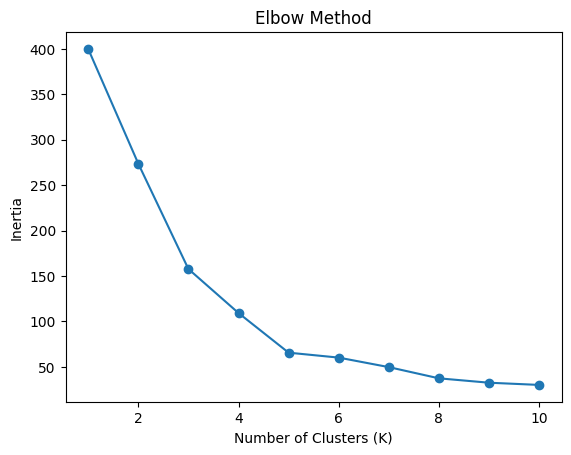

Silhouette Score: 0.5546571631111091


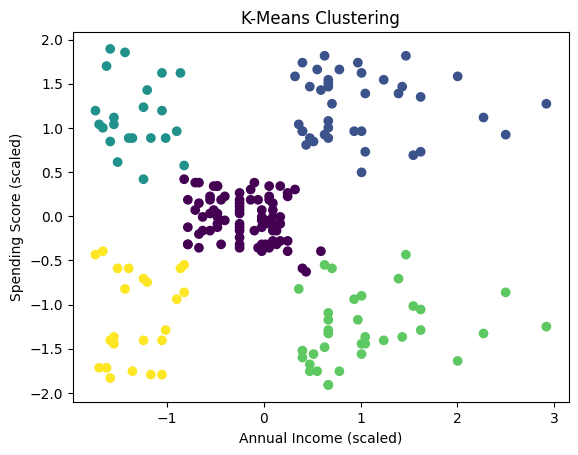

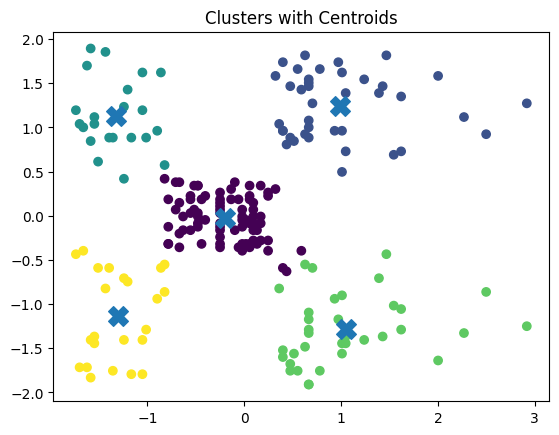

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("C:\\Users\\User\\Downloads\\ML\\EXP-7\\archive\\Mall_Customers.csv")

# Display first rows
print(df.head())

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Handle missing values (if any)
X = X.dropna()

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Elbow Method to find optimal K
# -------------------------------
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# -------------------------------
# Apply K-Means (choose K = 5)
# -------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = labels

# Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

# -------------------------------
# Visualization
# -------------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

# Centroids
centroids = kmeans.cluster_centers_
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X')
plt.title('Clusters with Centroids')
plt.show()

# -------------------------------
# Interpretation
# -------------------------------
print(df.groupby('Cluster').mean(numeric_only=True))